# Hybrid A* Demo (Educational)

This notebook shows a simplified Hybrid A* planner using states `(row, col, heading_bin)` and motion primitives.

It is designed for intuition, not production-level vehicle planning.

The notebook is organized as a step-by-step walkthrough: build the map, define heading-aware states and primitives, expand feasible motions, run the search, and visualize the resulting path.

In [33]:
%matplotlib inline

import heapq
import math

import matplotlib.pyplot as plt
import numpy as np

## 1. Build occupancy grid

This section creates a simple occupancy grid with blocked walls and narrow passages so the planner must reason about how to approach the goal with heading-aware motions.

In [34]:
H, W = 45, 45
grid = np.zeros((H, W), dtype=np.uint8)

# Obstacles
grid[8:37, 14] = 1
grid[8:37, 30] = 1
grid[22, 14:31] = 1

# Open corridors
grid[12, 14] = 0
grid[32, 30] = 0
grid[22, 22] = 0

start_xy = (5.0, 5.0)
goal_xy = (39.0, 39.0)
start_heading = math.radians(0.0)
goal_heading = math.radians(0.0)

## 2. State and motion settings

Here we define the heading discretization, primitive step length, steering choices, and helper functions that convert between continuous pose values and grid-aligned states.

In [11]:
N_HEADINGS = 16
STEP_LEN = 1.8
STEER_DELTAS = [-math.radians(25), 0.0, math.radians(25)]
GOAL_POS_TOL = 0
GOAL_HEADING_TOL_BINS = 1

def wrap_angle(theta):
    return (theta + 2.0 * math.pi) % (2.0 * math.pi)

def heading_to_bin(theta):
    t = wrap_angle(theta)
    return int(round((t / (2.0 * math.pi)) * N_HEADINGS)) % N_HEADINGS

def bin_to_heading(k):
    return (2.0 * math.pi) * (k / N_HEADINGS)

def heading_bin_distance(a, b):
    diff = abs(a - b)
    return min(diff, N_HEADINGS - diff)

def to_grid(xy):
    r = int(round(xy[0]))
    c = int(round(xy[1]))
    return r, c

def in_bounds(r, c):
    return 0 <= r < H and 0 <= c < W

def free_cell(r, c):
    return in_bounds(r, c) and grid[r, c] == 0

## 3. Motion primitive expansion

This section defines how one Hybrid A* state generates its successors. Each primitive updates heading, moves the vehicle forward by a fixed step, rejects collisions, and assigns a heuristic that combines position error with heading mismatch.

In [12]:
def primitive_successor(state, steer_delta):
    r, c, hb = state
    theta = bin_to_heading(hb)

    theta2 = wrap_angle(theta + steer_delta)
    nr = r + STEP_LEN * math.sin(theta2)
    nc = c + STEP_LEN * math.cos(theta2)

    # Sample along the primitive so short obstacles cannot be skipped by endpoint rounding.
    for t in np.linspace(0.0, 1.0, 9):
        sr = (1.0 - t) * r + t * nr
        sc = (1.0 - t) * c + t * nc
        gr, gc = to_grid((sr, sc))
        if not free_cell(gr, gc):
            return None

    gr, gc = to_grid((nr, nc))
    hb2 = heading_to_bin(theta2)
    return (float(gr), float(gc), hb2), STEP_LEN

def heuristic(state, goal_state):
    r, c, hb = state
    gr, gc, ghb = goal_state

    pos = math.hypot(gr - r, gc - c)
    dhead = heading_bin_distance(hb, ghb)
    return pos + 0.3 * dhead

## 4. Hybrid A* search

This is the main search loop. It keeps an A*-style priority queue over heading-aware states, expands feasible primitives, and stops when the planner reaches the goal pose within small position and heading tolerances.

In [13]:
def reconstruct(parent, node):
    path = [node]
    while node in parent:
        node = parent[node]
        path.append(node)
    path.reverse()
    return path

def hybrid_astar(start_state, goal_state):
    open_heap = []
    parent = {}
    g = {start_state: 0.0}
    closed = set()

    heapq.heappush(open_heap, (heuristic(start_state, goal_state), 0.0, start_state))
    expansions = 0

    while open_heap:
        _, curr_g, current = heapq.heappop(open_heap)
        if current in closed:
            continue

        closed.add(current)
        expansions += 1

        pos_ok = (abs(int(round(current[0])) - int(round(goal_state[0]))) <= GOAL_POS_TOL and
                  abs(int(round(current[1])) - int(round(goal_state[1]))) <= GOAL_POS_TOL)
        heading_ok = heading_bin_distance(current[2], goal_state[2]) <= GOAL_HEADING_TOL_BINS

        if pos_ok and heading_ok:
            return reconstruct(parent, current), g[current], expansions

        for steer in STEER_DELTAS:
            nxt = primitive_successor(current, steer)
            if nxt is None:
                continue

            ns, step_cost = nxt
            ng = curr_g + step_cost
            if ng < g.get(ns, math.inf):
                g[ns] = ng
                parent[ns] = current
                f = ng + heuristic(ns, goal_state)
                heapq.heappush(open_heap, (f, ng, ns))

    return None, math.inf, expansions

## 5. Run planner

This cell converts the start and goal poses into discrete planner states, runs the Hybrid A* search, and reports whether a path was found along with path cost and node expansions.

In [14]:
start_state = (float(round(start_xy[0])), float(round(start_xy[1])), heading_to_bin(start_heading))
goal_state = (float(round(goal_xy[0])), float(round(goal_xy[1])), heading_to_bin(goal_heading))

path, cost, expansions = hybrid_astar(start_state, goal_state)

print(f'Path found: {path is not None}')
print(f'Path cost: {cost:.2f}')
print(f'Node expansions: {expansions}')

Path found: True
Path cost: 45.00
Node expansions: 117


## 6. Visualize result

The final plot overlays the recovered path on the occupancy grid and draws sparse heading arrows so you can see how orientation changes along the route.

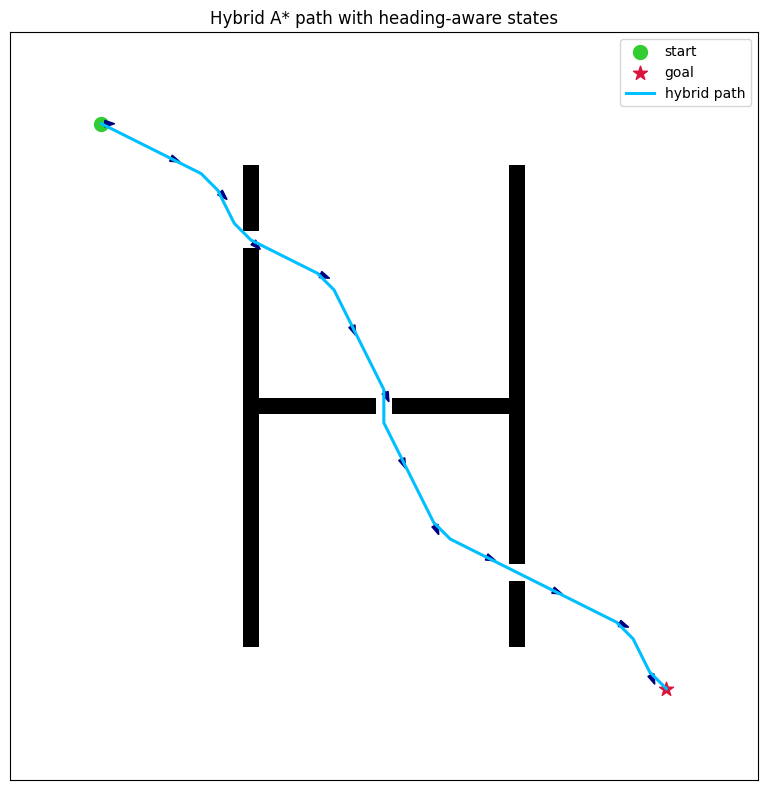

In [39]:
fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(grid, cmap='Greys', origin='upper')

ax.scatter(start_state[1], start_state[0], c='limegreen', s=100, marker='o', label='start')
ax.scatter(goal_state[1], goal_state[0], c='crimson', s=110, marker='*', label='goal')

if path is not None and len(path) > 1:
    xs = [p[1] for p in path]
    ys = [p[0] for p in path]
    ax.plot(xs, ys, color='deepskyblue', linewidth=2.2, label='hybrid path')

    # Draw sparse heading arrows
    stride = max(1, len(path) // 12)
    for p in path[::stride]:
        theta = bin_to_heading(p[2])
        dr = 0.8 * math.sin(theta)
        dc = 0.8 * math.cos(theta)
        ax.arrow(p[1], p[0], dc, dr, color='navy', head_width=0.4, length_includes_head=True)

ax.set_title('Hybrid A* path with heading-aware states')
ax.set_xticks([])
ax.set_yticks([])
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

## 7. Notes

This notebook focuses on the key concept: searching a heading-aware state space with feasible motion primitives.

For simplicity, this demo collision-checks a small set of sampled points along each primitive. Production implementations typically use denser sampling or full vehicle-footprint checks along the entire motion.

The demo now requires the final state to satisfy both a goal-position test and a small heading-bin tolerance. Production planners usually define these tolerances directly in continuous pose space.

Reverse motion primitives are omitted for simplicity.

Production planners often use Dubins, Reeds-Shepp, or 2D grid-search heuristics to improve efficiency.

Real Hybrid A* systems often add reverse gear, smoother curvature handling, analytic expansion near the goal, and post-optimization.